In [82]:
# Core
import json
import numpy as np
import pandas as pd

# Visualization (unchanged)
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# PyTorch (replaces TensorFlow/Keras)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import optuna



In [2]:
# Device setup (PyTorch equivalent of TF GPU check)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)

if DEVICE.type == "cuda":
    print("GPU Name:", torch.cuda.get_device_name(0))
    print("CUDA Version:", torch.version.cuda)


Using device: cuda
GPU Name: NVIDIA GeForce GTX 1650
CUDA Version: 13.0


In [3]:
# Load the dataset
url = '../data/raw/parkinsons_updrs.data.csv'
data = pd.read_csv(url)

# Drop unnecessary columns
data = data.drop(columns=['subject#', 'test_time'])

# Separate features and targets
X = data.drop(columns=['motor_UPDRS', 'total_UPDRS'])
y = data[['motor_UPDRS', 'total_UPDRS']]

# Split the data into training and testing sets
X_trainVal_raw, X_test_raw, y_trainVal, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Further split the training data into training and validation sets
X_train_raw, X_val_raw, y_train, y_val = train_test_split(X_trainVal_raw, y_trainVal, test_size=0.2, random_state=42)

In [4]:
# Scale the features
scaler = StandardScaler()
X_processed = scaler.fit_transform(X)
X_trainVal = scaler.fit_transform(X_trainVal_raw)
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)
X_val = scaler.fit_transform(X_val_raw)
feature_names = X.columns

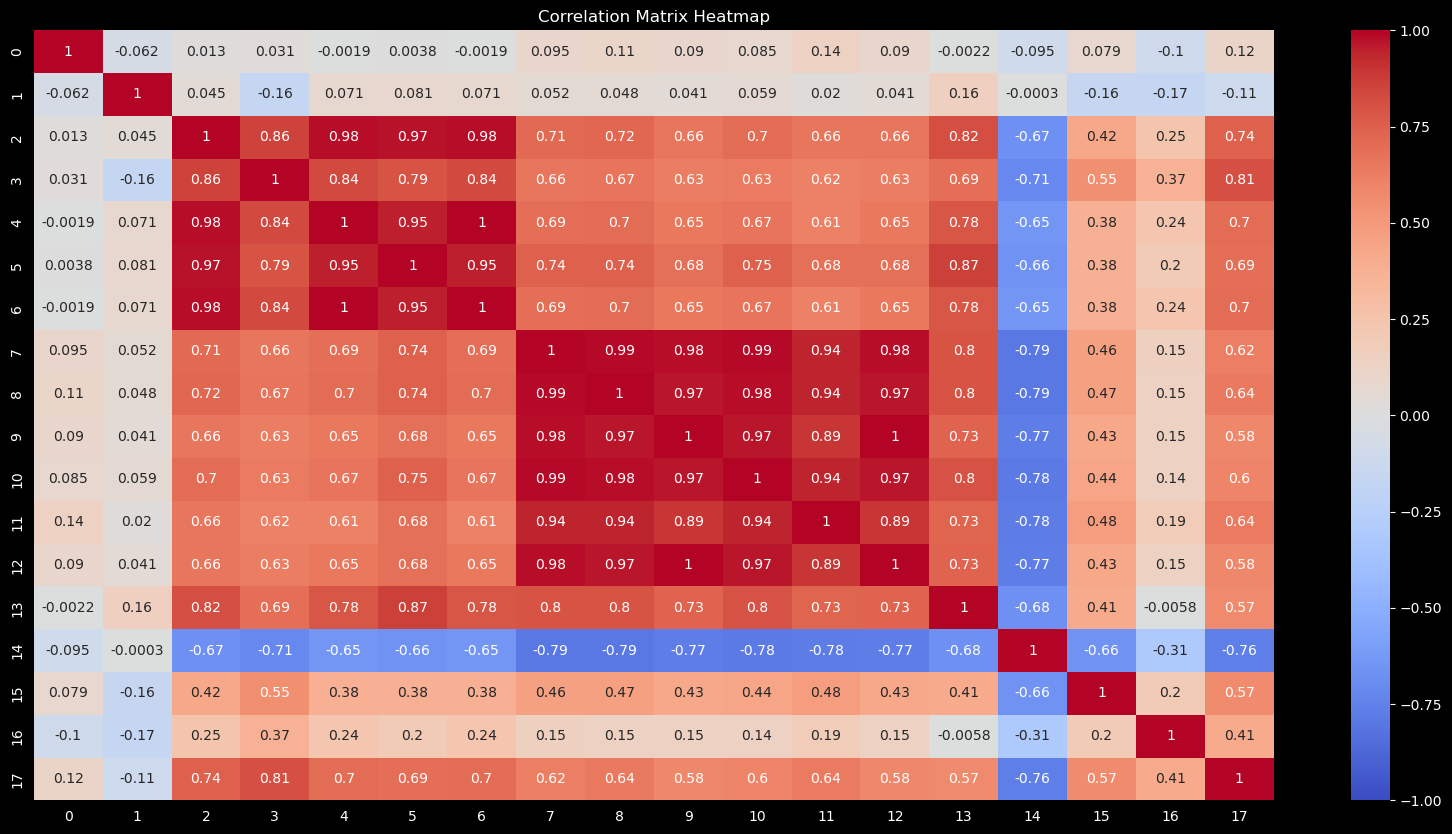

In [5]:
corr_matrix = pd.DataFrame(X_train).corr()

plt.figure(figsize=(20, 10))  # Adjust the figure size if necessary
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix Heatmap')
plt.show()

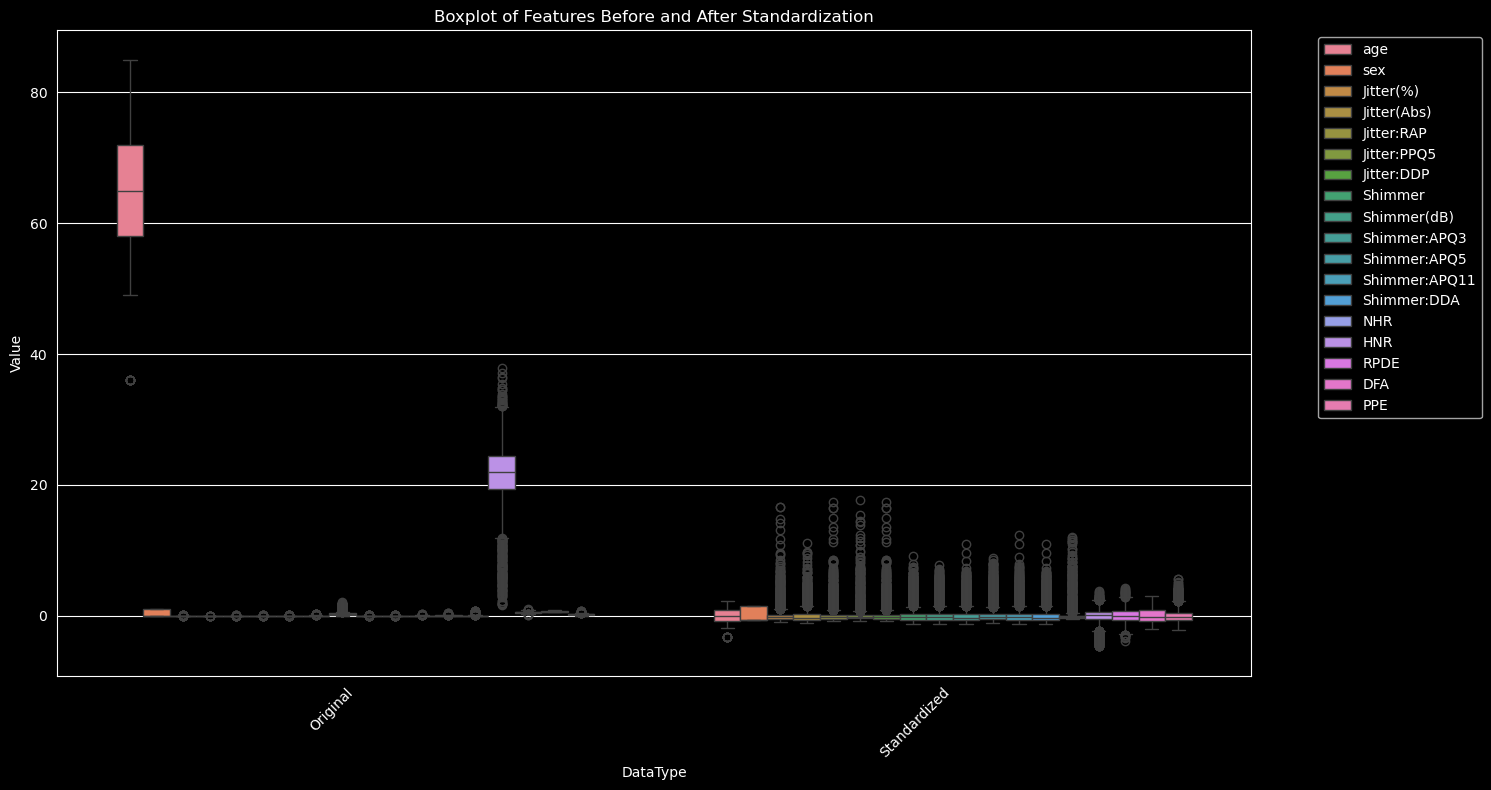

In [6]:
def plot_boxplots(original_data, scaled_data, feature_names):
    df_original = pd.DataFrame(original_data, columns=feature_names)
    df_scaled = pd.DataFrame(scaled_data, columns=feature_names)

    df_original['DataType'] = 'Original'
    df_scaled['DataType'] = 'Standardized'

    df_combined = pd.concat([df_original, df_scaled], ignore_index=True)

    plt.figure(figsize=(15, 8))
    # Melt the DataFrame to long format for seaborn
    df_melted = df_combined.melt(id_vars='DataType', var_name='Feature', value_name='Value')
    sns.boxplot(data=df_melted, x='DataType', y='Value', hue='Feature') # Use 'Value' for y-axis
    plt.title('Boxplot of Features Before and After Standardization')
    plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside the plot
    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.show()

# Assuming feature_names is a list of your feature names
plot_boxplots(X, X_processed, feature_names)

In [7]:
# Scale targets (same as before)
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train)
y_val_scaled   = y_scaler.transform(y_val)


In [8]:
class ParkinsonDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [10]:

STUDY_NAME = "parkinsons_nn_optuna"
DB_PATH = "sqlite:///parkinsons_optuna.db"

study = optuna.create_study(
    study_name=STUDY_NAME,
    direction="minimize",
    storage=DB_PATH,
    load_if_exists=True
)

print("Study loaded. Trials so far:", len(study.trials))


/e/conda/envs/ml/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-02-04 13:48:39,433] A new study created in RDB with name: parkinsons_nn_optuna


Study loaded. Trials so far: 0


In [11]:
class ParkinsonNN(nn.Module):
    def __init__(self, trial, input_dim=18):
        super().__init__()

        # Hyperparameters to search
        l1 = trial.suggest_int("units_l1", 64, 256, step=64)
        l2 = trial.suggest_int("units_l2", 64, 128, step=32)
        l3 = trial.suggest_int("units_l3", 32, 64, step=16)
        l4 = trial.suggest_int("units_l4", 32, 64, step=16)

        dropout = trial.suggest_float("dropout", 0.0, 0.3)

        self.net = nn.Sequential(
            nn.Linear(input_dim, l1), nn.ReLU(),
            nn.Linear(l1, l2), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(l2, l3), nn.ReLU(),
            nn.Linear(l3, l4), nn.ReLU(),
            nn.Linear(l4, 2)
        )

    def forward(self, x):
        return self.net(x)


In [12]:
def objective(trial):

    lr = trial.suggest_categorical("lr", [1e-3, 1e-2, 1e-1])
    weight_decay = trial.suggest_categorical("l2", [1e-4, 1e-3, 1e-2])
    batch_size = 32

    train_ds = ParkinsonDataset(X_train, y_train_scaled)
    val_ds   = ParkinsonDataset(X_val, y_val_scaled)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size)

    model = ParkinsonNN(trial).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    best_val = float("inf")
    patience = 20
    patience_ctr = 0

    for epoch in range(300):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

        # validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                val_loss += criterion(model(xb), yb).item()

        val_loss /= len(val_loader)

        # Early stopping
        if val_loss < best_val:
            best_val = val_loss
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                break

    return best_val


In [13]:
study.optimize(objective, n_trials=20)


[I 2026-02-04 13:49:52,439] Trial 0 finished with value: 0.9596310178438823 and parameters: {'lr': 0.1, 'l2': 0.0001, 'units_l1': 192, 'units_l2': 64, 'units_l3': 48, 'units_l4': 64, 'dropout': 0.10386141098890193}. Best is trial 0 with value: 0.9596310178438823.
[I 2026-02-04 13:50:08,956] Trial 1 finished with value: 0.14194887640575568 and parameters: {'lr': 0.001, 'l2': 0.0001, 'units_l1': 64, 'units_l2': 96, 'units_l3': 32, 'units_l4': 48, 'dropout': 0.07934546296773166}. Best is trial 1 with value: 0.14194887640575568.
[I 2026-02-04 13:50:12,846] Trial 2 finished with value: 0.9587647626797359 and parameters: {'lr': 0.1, 'l2': 0.0001, 'units_l1': 64, 'units_l2': 64, 'units_l3': 48, 'units_l4': 48, 'dropout': 0.13942207343797355}. Best is trial 1 with value: 0.14194887640575568.
[I 2026-02-04 13:50:29,936] Trial 3 finished with value: 0.22937997231880825 and parameters: {'lr': 0.01, 'l2': 0.001, 'units_l1': 128, 'units_l2': 96, 'units_l3': 64, 'units_l4': 64, 'dropout': 0.26636504

In [14]:
print("Best trial:")
print(study.best_trial.params)


Best trial:
{'lr': 0.001, 'l2': 0.0001, 'units_l1': 64, 'units_l2': 96, 'units_l3': 32, 'units_l4': 48, 'dropout': 0.07934546296773166}


In [15]:
best_params = study.best_trial.params
print(best_params)

# Save to disk (reproducibility!)
with open("../models/best_nn_params.json", "w") as f:
    json.dump(best_params, f, indent=4)

print("Saved best_nn_params.json")


{'lr': 0.001, 'l2': 0.0001, 'units_l1': 64, 'units_l2': 96, 'units_l3': 32, 'units_l4': 48, 'dropout': 0.07934546296773166}
Saved best_nn_params.json


In [16]:
# Load params (important for future reruns)
with open("../models/best_nn_params.json", "r") as f:
    params = json.load(f)

params


{'lr': 0.001,
 'l2': 0.0001,
 'units_l1': 64,
 'units_l2': 96,
 'units_l3': 32,
 'units_l4': 48,
 'dropout': 0.07934546296773166}

In [17]:
class FinalParkinsonNN(nn.Module):
    def __init__(self, params, input_dim=18):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, params["units_l1"]), nn.ReLU(),
            nn.Linear(params["units_l1"], params["units_l2"]), nn.ReLU(),
            nn.Dropout(params["dropout"]),
            nn.Linear(params["units_l2"], params["units_l3"]), nn.ReLU(),
            nn.Linear(params["units_l3"], params["units_l4"]), nn.ReLU(),
            nn.Linear(params["units_l4"], 2)
        )

    def forward(self, x):
        return self.net(x)


In [46]:
BATCH_SIZE = 32
LR = params["lr"]
WEIGHT_DECAY = params["l2"]

train_ds = ParkinsonDataset(X_train, y_train_scaled)
val_ds   = ParkinsonDataset(X_val, y_val_scaled)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE)

best_NN_model = FinalParkinsonNN(params).to(DEVICE)

optimizer = torch.optim.Adam(
    best_NN_model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

criterion = nn.MSELoss()


In [60]:
best_val = float("inf")
patience = 100
patience_ctr = 0

for epoch in range(500):
    best_NN_model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        optimizer.zero_grad()
        loss = criterion(best_NN_model(xb), yb)
        loss.backward()
        optimizer.step()

    # validation
    best_NN_model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            val_loss += criterion(best_NN_model(xb), yb).item()

    val_loss /= len(val_loader)
    print(f"Epoch {epoch+1}  Val MSE: {val_loss:.4f}")

    if val_loss < best_val:
        best_val = val_loss
        patience_ctr = 0
        torch.save(best_NN_model.state_dict(), "../models/best_nn_model.pt")
    else:
        patience_ctr += 1
        if patience_ctr >= patience:
            print("Early stopping")
            break


Epoch 1  Val MSE: 0.1637
Epoch 2  Val MSE: 0.1567
Epoch 3  Val MSE: 0.1678
Epoch 4  Val MSE: 0.1679
Epoch 5  Val MSE: 0.1718
Epoch 6  Val MSE: 0.1873
Epoch 7  Val MSE: 0.1660
Epoch 8  Val MSE: 0.1734
Epoch 9  Val MSE: 0.1751
Epoch 10  Val MSE: 0.1726
Epoch 11  Val MSE: 0.1676
Epoch 12  Val MSE: 0.1792
Epoch 13  Val MSE: 0.1649
Epoch 14  Val MSE: 0.1585
Epoch 15  Val MSE: 0.1604
Epoch 16  Val MSE: 0.1621
Epoch 17  Val MSE: 0.1647
Epoch 18  Val MSE: 0.1542
Epoch 19  Val MSE: 0.1724
Epoch 20  Val MSE: 0.1667
Epoch 21  Val MSE: 0.1673
Epoch 22  Val MSE: 0.1638
Epoch 23  Val MSE: 0.1746
Epoch 24  Val MSE: 0.1696
Epoch 25  Val MSE: 0.2474
Epoch 26  Val MSE: 0.1701
Epoch 27  Val MSE: 0.1766
Epoch 28  Val MSE: 0.1882
Epoch 29  Val MSE: 0.1738
Epoch 30  Val MSE: 0.1690
Epoch 31  Val MSE: 0.1716
Epoch 32  Val MSE: 0.1662
Epoch 33  Val MSE: 0.1719
Epoch 34  Val MSE: 0.1777
Epoch 35  Val MSE: 0.1688
Epoch 36  Val MSE: 0.1775
Epoch 37  Val MSE: 0.1731
Epoch 38  Val MSE: 0.1680
Epoch 39  Val MSE: 0.

In [61]:
best_NN_model.load_state_dict(torch.load("../models/best_nn_model.pt"))
best_NN_model.eval()


FinalParkinsonNN(
  (net): Sequential(
    (0): Linear(in_features=18, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=96, bias=True)
    (3): ReLU()
    (4): Dropout(p=0.07934546296773166, inplace=False)
    (5): Linear(in_features=96, out_features=32, bias=True)
    (6): ReLU()
    (7): Linear(in_features=32, out_features=48, bias=True)
    (8): ReLU()
    (9): Linear(in_features=48, out_features=2, bias=True)
  )
)

In [62]:
# Convert test features to tensor
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)

# Run inference
with torch.no_grad():
    y_pred_scaled = best_NN_model(X_test_tensor).cpu().numpy()

# 🔴 IMPORTANT: inverse scaling (you scaled targets earlier)
y_pred = y_scaler.inverse_transform(y_pred_scaled)

# Metrics (same as before)
mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f"Test MSE: {mse:.4f}")
print(f"R-squared Score: {r2:.4f}")

Test MSE: 15.8491
R-squared Score: 0.8162


In [63]:
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")


RMSE: 3.9811
MAE:  2.6309


In [43]:
with open("../models/best_rf1_params.json", "r") as f:
    rf_params = json.load(f)

rf_params["criterion"] = "squared_error"
rf_params["n_jobs"] = -1
rf_params["random_state"] = 42

final_rf1 = RandomForestRegressor(**rf_params)
final_rf1.fit(X_trainVal, y_trainVal)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",40
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [44]:
rf_preds = final_rf1.predict(X_test)

mse = mean_squared_error(y_test, rf_preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, rf_preds)
mae = mean_absolute_error(y_test, rf_preds)

print("RF Test Metrics")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)


RF Test Metrics
MSE : 7.005720561765958
RMSE: 2.646832174839568
MAE : 1.9071468373404246
R2  : 0.9183587681573446


In [100]:
from xgboost import XGBRegressor

def xgb_motor_objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 800, step=100),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 2),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 2.0),
        "objective": "reg:squarederror",
        "random_state": 42,
        "n_jobs": -1
    }

    model = XGBRegressor(**params)
    model.fit(X_trainVal, y_trainVal["motor_UPDRS"])

    preds = model.predict(X_val)
    mse = mean_squared_error(y_val["motor_UPDRS"], preds)

    return mse
def xgb_total_objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 800, step=100),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 2),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 2.0),
        "objective": "reg:squarederror",
        "random_state": 42,
        "n_jobs": -1
    }

    model = XGBRegressor(**params)
    model.fit(X_trainVal, y_trainVal["total_UPDRS"])

    preds = model.predict(X_val)
    mse = mean_squared_error(y_val["total_UPDRS"], preds)

    return mse



In [104]:
XGB_MOTOR_STUDY_NAME = "parkinsons_xgb_motor_optuna"
XGB_MOTOR_DB = "sqlite:///parkinsons_xgb_motor_optuna.db"

xgb_motor_study = optuna.create_study(
    study_name=XGB_MOTOR_STUDY_NAME,
    direction="minimize",
    storage=XGB_MOTOR_DB,
    load_if_exists=True
)

xgb_motor_study.optimize(xgb_motor_objective, n_trials=50)


[I 2026-02-04 16:19:20,559] Using an existing study with name 'parkinsons_xgb_motor_optuna' instead of creating a new one.
[I 2026-02-04 16:19:21,294] Trial 50 finished with value: 39.330038217084585 and parameters: {'n_estimators': 800, 'max_depth': 4, 'learning_rate': 0.09222621986754607, 'subsample': 0.6797686927359128, 'colsample_bytree': 0.6240976297150435, 'gamma': 0.9235691214354761, 'reg_lambda': 1.2826700098862533, 'reg_alpha': 1.8567397448395617}. Best is trial 46 with value: 34.73279737902001.
[I 2026-02-04 16:19:22,135] Trial 51 finished with value: 37.79282666640707 and parameters: {'n_estimators': 800, 'max_depth': 6, 'learning_rate': 0.07690155879429827, 'subsample': 0.714834673426507, 'colsample_bytree': 0.6698159449082258, 'gamma': 1.0954054596926763, 'reg_lambda': 0.46715261124037966, 'reg_alpha': 1.3050675908168439}. Best is trial 46 with value: 34.73279737902001.
[I 2026-02-04 16:19:24,503] Trial 52 finished with value: 37.204813634966 and parameters: {'n_estimators

In [105]:
XGB_total_STUDY_NAME = "parkinsons_xgb_total_optuna"
XGB_total_DB = "sqlite:///parkinsons_xgb_total_optuna.db"

xgb_total_study = optuna.create_study(
    study_name=XGB_total_STUDY_NAME,
    direction="minimize",
    storage=XGB_total_DB,
    load_if_exists=True
)

xgb_total_study.optimize(xgb_total_objective, n_trials=50)

[I 2026-02-04 16:21:15,893] Using an existing study with name 'parkinsons_xgb_total_optuna' instead of creating a new one.
[I 2026-02-04 16:21:17,892] Trial 50 finished with value: 61.85117909300733 and parameters: {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.02200225311711315, 'subsample': 0.6700329814880802, 'colsample_bytree': 0.6502810824232853, 'gamma': 0.46022116326603213, 'reg_lambda': 0.400072151837243, 'reg_alpha': 1.2737974079718668}. Best is trial 48 with value: 59.22316721627284.
[I 2026-02-04 16:21:20,929] Trial 51 finished with value: 60.72672339169311 and parameters: {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.02060533651955559, 'subsample': 0.6908777865355202, 'colsample_bytree': 0.6069945416767982, 'gamma': 0.6138435252063151, 'reg_lambda': 0.5471995296855263, 'reg_alpha': 1.0866780277371129}. Best is trial 48 with value: 59.22316721627284.
[I 2026-02-04 16:21:22,192] Trial 52 finished with value: 61.31779915649369 and parameters: {'n_estimator

In [108]:
best_xgb_motor_params = xgb_motor_study.best_trial.params
print(best_xgb_motor_params)

best_xgb_total_params = xgb_total_study.best_trial.params
print(best_xgb_total_params)
import json
with open("../models/best_xgb_motor_params.json", "w") as f:
    json.dump(best_xgb_motor_params, f, indent=4)

with open("../models/best_xgb_test_params.json", "w") as f:
    json.dump(best_xgb_total_params, f, indent=4)


{'n_estimators': 800, 'max_depth': 6, 'learning_rate': 0.07337407990596595, 'subsample': 0.6171322127493308, 'colsample_bytree': 0.7618524632189011, 'gamma': 0.9625862194616193, 'reg_lambda': 2.207926028880822, 'reg_alpha': 0.503044616722323}
{'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.02214401501192435, 'subsample': 0.6260076973201236, 'colsample_bytree': 0.6010827729509233, 'gamma': 0.5581667312173896, 'reg_lambda': 0.41141149694073853, 'reg_alpha': 1.0481160197329444}


In [93]:
from xgboost import XGBRegressor

with open("../models/best_xgb_params.json", "r") as f:
    xgb_params = json.load(f)

xgb_params["objective"] = "reg:squarederror"
xgb_params["random_state"] = 42
xgb_params["n_jobs"] = -1

base_xgb = XGBRegressor(**xgb_params)

# ⭐ THIS is the missing piece
final_xgb = MultiOutputRegressor(base_xgb)

final_xgb.fit(X_trainVal, y_trainVal)


,estimator estimator: estimator objectAn estimator object implementing :term:`fit` and :term:`predict`.,"XGBRegressor(...ree=None, ...)"
,"n_jobs n_jobs: int or None, optional (default=None)The number of jobs to run in parallel.:meth:`fit`, :meth:`predict` and :meth:`partial_fit` (if supportedby the passed estimator) will be parallelized for each target.When individual estimators are fast to train or predict,using ``n_jobs > 1`` can result in slower performance dueto the parallelism overhead.``None`` means `1` unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all available processes / threads.See :term:`Glossary ` for more details... versionchanged:: 0.20 `n_jobs` default changed from `1` to `None`.",None
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.6072742135031985
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None


In [94]:
xgb_preds = final_xgb.predict(X_test)

mse = mean_squared_error(y_test, xgb_preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, xgb_preds)

print("XGBoost Test Metrics")
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)


XGBoost Test Metrics
MSE : 90.54296875
RMSE: 9.515406914578062
R2  : -0.02947819232940674


In [92]:
# Randomly select an index from the test set
random_index = np.random.randint(0, len(X_test))

# Select the data point and its actual value
single_data_point = X_test[random_index].reshape(1, -1)
actual_value = y_test.iloc[random_index]

# ===============================
# Neural Network prediction (PyTorch)
# ===============================
best_NN_model.eval()

single_tensor = torch.tensor(single_data_point, dtype=torch.float32).to(DEVICE)

with torch.no_grad():
    nn_pred_scaled = best_NN_model(single_tensor).cpu().numpy()

# inverse scaling (VERY IMPORTANT)
predicted_value_NN = y_scaler.inverse_transform(nn_pred_scaled)

# ===============================
# Random Forest prediction
# ===============================
predicted_value_RF = final_rf1.predict(single_data_point)

# ===============================
# Simple Ensemble (Average)
# ===============================
y_val_pred_combined = (predicted_value_NN + predicted_value_RF) / 2

# ===============================
# Display results
# ===============================
print("Actual value (motor_UPDRS, total_UPDRS):", actual_value.values)
print("Predicted NN value:", predicted_value_NN[0])
print("Predicted RF value:", predicted_value_RF[0])
print("Predicted Average value:", y_val_pred_combined[0])


Actual value (motor_UPDRS, total_UPDRS): [17.67 26.67]
Predicted NN value: [25.841984 36.17622 ]
Predicted RF value: [18.21096   27.1804025]
Predicted Average value: [22.0264719  31.67831122]


In [67]:
# ===== Neural Network predictions (PyTorch) =====
best_NN_model.eval()
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)

with torch.no_grad():
    y_pred_scaled = best_NN_model(X_test_tensor).cpu().numpy()

# inverse scaling (CRITICAL)
y_pred_NN = y_scaler.inverse_transform(y_pred_scaled)

# ===== Random Forest predictions =====
y_pred_RF = final_rf1.predict(X_test)


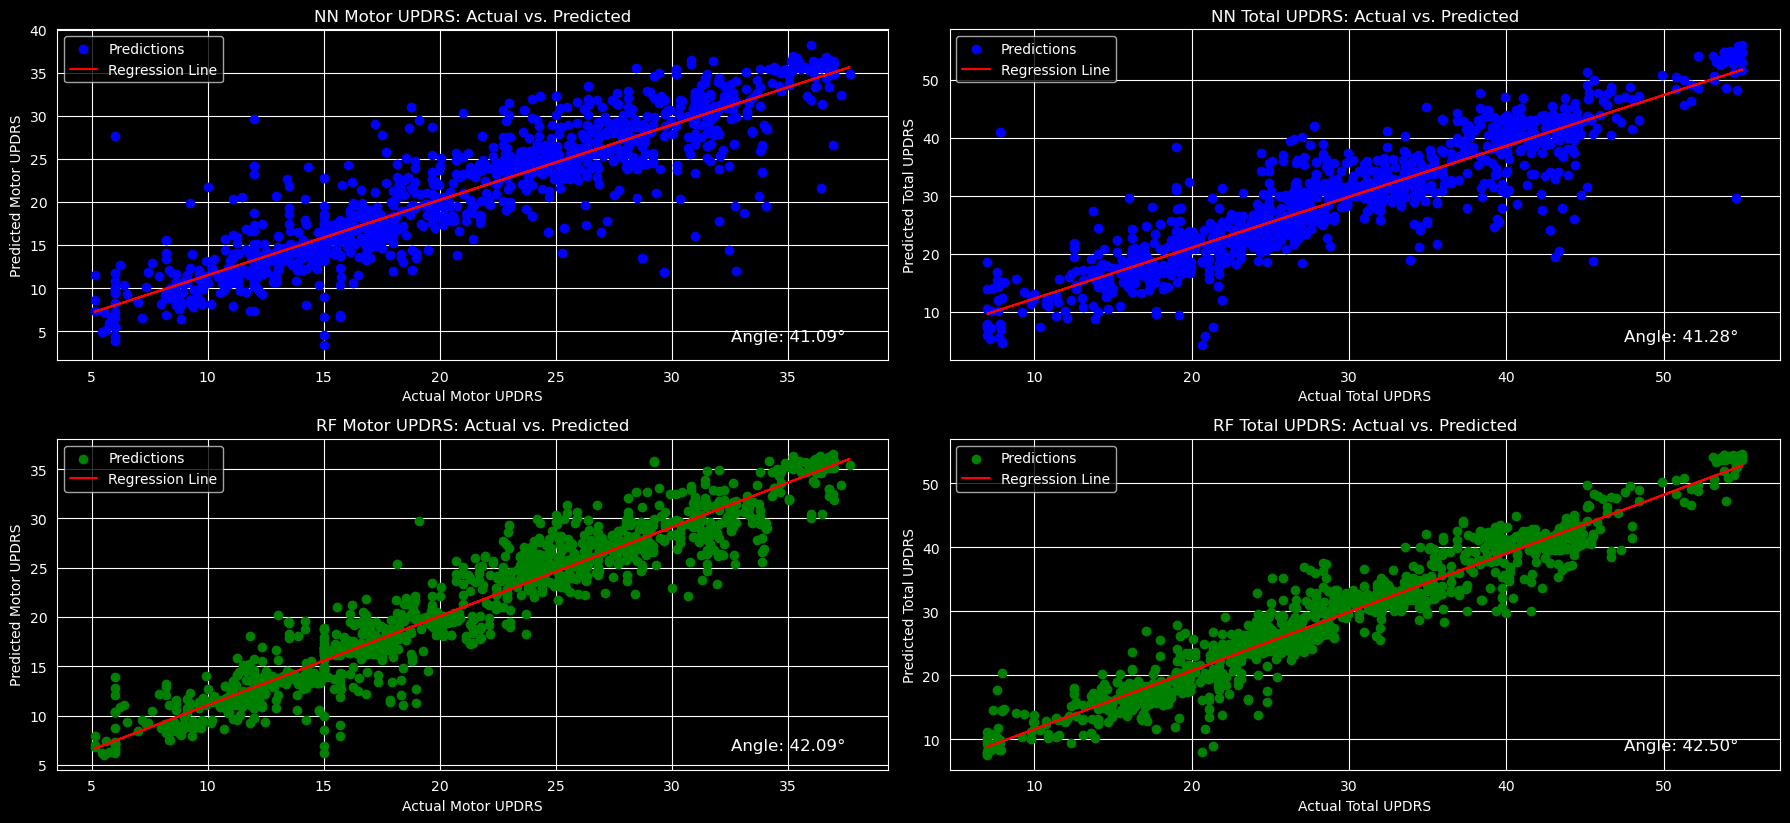

In [68]:
plt.figure(figsize=(18, 12))

def plot_with_angle(ax, actual, predicted, label, color, model_name):
    ax.scatter(actual, predicted, label='Predictions', color=color)

    slope, intercept = np.polyfit(actual, predicted, 1)
    regression_line = slope * actual + intercept
    ax.plot(actual, regression_line, color='red', label='Regression Line')

    angle = np.degrees(np.arctan(slope))
    ax.text(0.95, 0.05, f'Angle: {angle:.2f}°', transform=ax.transAxes,
            fontsize=12, verticalalignment='bottom', horizontalalignment='right')

    ax.set_xlabel(f'Actual {label}')
    ax.set_ylabel(f'Predicted {label}')
    ax.set_title(f'{model_name} {label}: Actual vs. Predicted')
    ax.legend()

# NN plots
plt.subplot(3, 2, 1)
plot_with_angle(plt.gca(), y_test['motor_UPDRS'], y_pred_NN[:, 0], 'Motor UPDRS', 'blue', 'NN')

plt.subplot(3, 2, 2)
plot_with_angle(plt.gca(), y_test['total_UPDRS'], y_pred_NN[:, 1], 'Total UPDRS', 'blue', 'NN')

# RF plots
plt.subplot(3, 2, 3)
plot_with_angle(plt.gca(), y_test['motor_UPDRS'], y_pred_RF[:, 0], 'Motor UPDRS', 'green', 'RF')

plt.subplot(3, 2, 4)
plot_with_angle(plt.gca(), y_test['total_UPDRS'], y_pred_RF[:, 1], 'Total UPDRS', 'green', 'RF')

plt.tight_layout()
plt.show()
